In [1]:
from experiments.dj.likelihood_tables import LikelihoodConfig
from experiments.dj.result_tables import (
    AdaptPriorResult,
    FlowPriorResult,
    LikelihoodResult,
)
from experiments.dj.prior_tables import FlowPriorConfig
from experiments.dj.trainer_tables import FPTrainerConfig, LLTrainerConfig
from experiments.dj.dataloader_tables import DataLoaderConfig
from experiments.dj.dj_helpers import fetch_best_model_results
import gensn.distributions as G
import torch
from task_transfer.ml_lib.data_loading import build_dataloaders
from task_transfer.evaluation.evaluate_generative_model import (
    evaluate_flow_prior,
    compute_logl,
    adapt_prior_eval_criterion,
    compute_joint_logl,
    logl_mc_marginal_eval,
)


from experiments.dj.posterior_tables import SBVGPConfig

from experiments.dj.sysident_tables import SIConfig
from experiments.dj.result_tables import SBVGPResult, SIResult, FlowPriorResult, AdaptPriorResult
from experiments.dj.dataloader_tables import DataLoaderConfig

from task_transfer.utils.insilico_stimuli import generate_gabors
from task_transfer.ml_lib.data_loading import build_dataloaders

from task_transfer.evaluation.evaluate_generative_model import compute_logl
from task_transfer.evaluation.evaluate_generative_model import (
    compute_logl_marginal,
    compute_logl_data_marginal,
)
import torch
import matplotlib.pyplot as plt
import seaborn as sns


import numpy as np
from task_transfer.utils.math_utils import cos2_von_mises

from task_transfer.utils.model_utils import build_haefner_model

torch.manual_seed(42)

import experiments.orientation_discrimination.haefner_model.configs as cfg

[2024-07-11 12:10:26,699][INFO]: Connecting sshrinivasan@134.76.19.44:3306
[2024-07-11 12:10:27,942][INFO]: Connected sshrinivasan@134.76.19.44:3306
/usr/local/lib/python3.8/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")


In [2]:
import wandb

wandb.init(project="random", entity="walkerlab")

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


wandb: Currently logged in as: sshr (walkerlab). Use `wandb login --relogin` to force relogin


In [3]:
AdaptPriorResult()

seed,prior_fp_id to index into FlowPriorConfig,prior_trainer_id to index into FPTrainerConfig,likelihood_id to index into LikelihoodConfig,likelihood_trainer_id to index into LLTrainerConfig,orig_dl_id to index into DataLoaderConfig used for the prior and likelihood training,trainer_id,dl_id,"train_marginal_obs_ll_mean mean per trial, per sample, in nats",train_marginal_obs_ll_sem standard error of the mean,val_marginal_obs_ll_mean,val_marginal_obs_ll_sem,test_marginal_obs_ll_mean,test_marginal_obs_ll_sem,"train_prior_ll_mean mean per trial, per sample, in nats",train_prior_ll_sem standard error of the mean,val_prior_ll_mean,val_prior_ll_sem,test_prior_ll_mean,test_prior_ll_sem,tracker_output,eval_output,model trained joint model NOT just the prior
-100,d0cf491f03b7f839c8a54834a6168081,c40a50ce9c77369770dddd5129836477,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,e267b2071bca2c3f9431f155e8e58f23,260a5ea8175f75eaef132f42873ad14a,-5339.22021484375,623.21923828125,-5353.14404296875,1219.138671875,-5373.67822265625,1560.8585205078125,-225.44107055664062,3.2020812034606934,-225.2079620361328,5.9614667892456055,-224.12705993652344,8.175251007080078,=BLOB=,=BLOB=,=BLOB=
-100,d0cf491f03b7f839c8a54834a6168081,c40a50ce9c77369770dddd5129836477,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,e267b2071bca2c3f9431f155e8e58f23,9ef3ae6fea33eba634d928a88b866836,-5203.6923828125,593.451171875,-5200.5927734375,1111.11376953125,-5184.78564453125,1497.9891357421875,-225.7065887451172,3.2274301052093506,-225.50997924804688,6.009249210357666,-224.40745544433594,8.13746452331543,=BLOB=,=BLOB=,=BLOB=
42,89c1053a65023b042dc63f7f852bb5b0,f89651063b51487dcdf4041336ef89db,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,e267b2071bca2c3f9431f155e8e58f23,260a5ea8175f75eaef132f42873ad14a,-4452.72412109375,501.619140625,-4446.9677734375,931.7738647460938,-4504.203125,1262.531982421875,-4787.8984375,381.42791748046875,-4756.22119140625,715.9622192382812,-4610.33740234375,933.390625,=BLOB=,=BLOB=,=BLOB=
42,d0cf491f03b7f839c8a54834a6168081,c40a50ce9c77369770dddd5129836477,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,6a40e4f70ae9e60ad158a5da6db1661d,260a5ea8175f75eaef132f42873ad14a,-5508.91650390625,709.6250610351562,-5511.12744140625,1374.79931640625,-5575.3623046875,1756.187255859375,-189.88673400878906,2.256335973739624,-189.78884887695312,4.225911617279053,-189.56430053710938,6.074876308441162,=BLOB=,=BLOB=,=BLOB=
42,d0cf491f03b7f839c8a54834a6168081,c40a50ce9c77369770dddd5129836477,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,e267b2071bca2c3f9431f155e8e58f23,9ef3ae6fea33eba634d928a88b866836,-4989.09033203125,581.8089599609375,-4902.71240234375,996.241455078125,-4779.85595703125,1295.3453369140625,-123.60945892333984,2.029911994934082,-123.82306671142578,3.7798922061920166,-123.90569305419922,5.306024074554443,=BLOB=,=BLOB=,=BLOB=


In [4]:
adapted_prior = (AdaptPriorResult & "dl_id = '260a5ea8175f75eaef132f42873ad14a'").fetch(
    download_path="/tmp",
    order_by="val_marginal_obs_ll_mean DESC",
    limit=1,
    as_dict=True,
)[0]

In [5]:
adapted_prior_model = torch.load(adapted_prior["model"], map_location="cpu")

In [6]:
download_path = "/tmp"
criterion = "val_ll_mean"
k = 1

prior_config_proj_col = "fp_id"
best_val_prior_results = fetch_best_model_results(
    result_table=FlowPriorResult,
    config_table=FlowPriorConfig,
    data_loader_config_table=DataLoaderConfig,
    trainer_config_table=FPTrainerConfig,
    config_proj_col=prior_config_proj_col,
    criterion=criterion,
    k=k,
    download_path=download_path,
)
prior_model = torch.load(best_val_prior_results["model"], map_location="cpu")

# get likelihood model for marginal likelihood
likelihood_config_proj_col = "ll_id"
best_val_likelihood_results = fetch_best_model_results(
    result_table=LikelihoodResult,
    config_table=LikelihoodConfig,
    data_loader_config_table=DataLoaderConfig,
    trainer_config_table=LLTrainerConfig,
    config_proj_col=likelihood_config_proj_col,
    criterion=criterion,
    k=k,
    download_path=download_path,
)
likelihood_model = torch.load(best_val_likelihood_results["model"], map_location="cpu")

dataloader_args = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
}
train_loader, val_loader, test_loader = build_dataloaders(
    data_fname=dataloader_args["data_fname"],
    train_prop=dataloader_args["train_prop"],
    val_prop=dataloader_args["val_prop"],
    batch_size=128,
)

joint_model = G.Joint(
    prior=prior_model, conditional=likelihood_model
)

In [7]:
haefner_model = build_haefner_model(
    p_c=cfg.orginal_haefner_2afc_task1['p_c'],
    c1_psi=cfg.orginal_haefner_2afc_task1['c1_psi'],
    c2_psi=cfg.orginal_haefner_2afc_task1['c2_psi'],
    kappa=cfg.orginal_haefner_2afc_task1['kappa'],
    g_phi=cfg.orginal_haefner_2afc_task1['g_phi'],
    delta=cfg.orginal_haefner_2afc_task1['delta'],
    lam=cfg.orginal_haefner_2afc_task1['lam'],
    x_phi=cfg.orginal_haefner_2afc_task1['x_phi'],
    obs_sigma=cfg.orginal_haefner_2afc_task1['obs_sigma'],
    obs_h=cfg.orginal_haefner_2afc_task1['obs_h'],
    obs_w=cfg.orginal_haefner_2afc_task1['obs_w'],
)

In [8]:
def haefner_prior_sampling_fn(haefner_model, n_samples):
    samples = haefner_model.sample_prior(n_samples=n_samples)
    return samples["x_samples"]

In [9]:
data_dim = 1
cond_dim = 0
mc_sample_size=10_000
device="cpu"
reduction="none"
uncertainty="sem"
normalize="none"
unit="nats"
true_logl_marg_train, _ = compute_logl_marginal(
    conditional=likelihood_model,
    prior=haefner_model,
    mc_sample_size=mc_sample_size,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
    prior_sampling_fn=haefner_prior_sampling_fn,
)
true_logl_marg_val, _ = compute_logl_marginal(
    conditional=likelihood_model,
    prior=haefner_model,
    mc_sample_size=mc_sample_size,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
    prior_sampling_fn=haefner_prior_sampling_fn,
)
true_logl_marg_test, _ = compute_logl_marginal(
    conditional=likelihood_model,
    prior=haefner_model,
    mc_sample_size=mc_sample_size,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
    prior_sampling_fn=haefner_prior_sampling_fn,
)

In [10]:
true_data_logl_marg_train, _ = compute_logl_data_marginal(
    conditional_model=likelihood_model,
    data_loader=train_loader,
    data_dim=data_dim,
    cond_dim=cond_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
true_data_logl_marg_val, _ = compute_logl_data_marginal(
    conditional_model=likelihood_model,
    data_loader=val_loader,
    data_dim=data_dim,
    cond_dim=cond_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
true_data_logl_marg_test, _ = compute_logl_data_marginal(
    conditional_model=likelihood_model,
    data_loader=test_loader,
    data_dim=data_dim,
    cond_dim=cond_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

In [11]:
logl_mc_marg_pre_task_train, _ = logl_mc_marginal_eval(
    joint_model=joint_model,
    data_loader=train_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
logl_mc_marg_pre_task_val, _ = logl_mc_marginal_eval(
    joint_model=joint_model,
    data_loader=val_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
logl_mc_marg_pre_task_test, _ = logl_mc_marginal_eval(
    joint_model=joint_model,
    data_loader=test_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

In [12]:
logl_mc_marg_adpt_train, _ = logl_mc_marginal_eval(
    joint_model=adapted_prior_model,
    data_loader=train_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
logl_mc_marg_adpt_val, _ = logl_mc_marginal_eval(
    joint_model=adapted_prior_model,
    data_loader=val_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
logl_mc_marg_adpt_test, _ = logl_mc_marginal_eval(
    joint_model=adapted_prior_model,
    data_loader=test_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

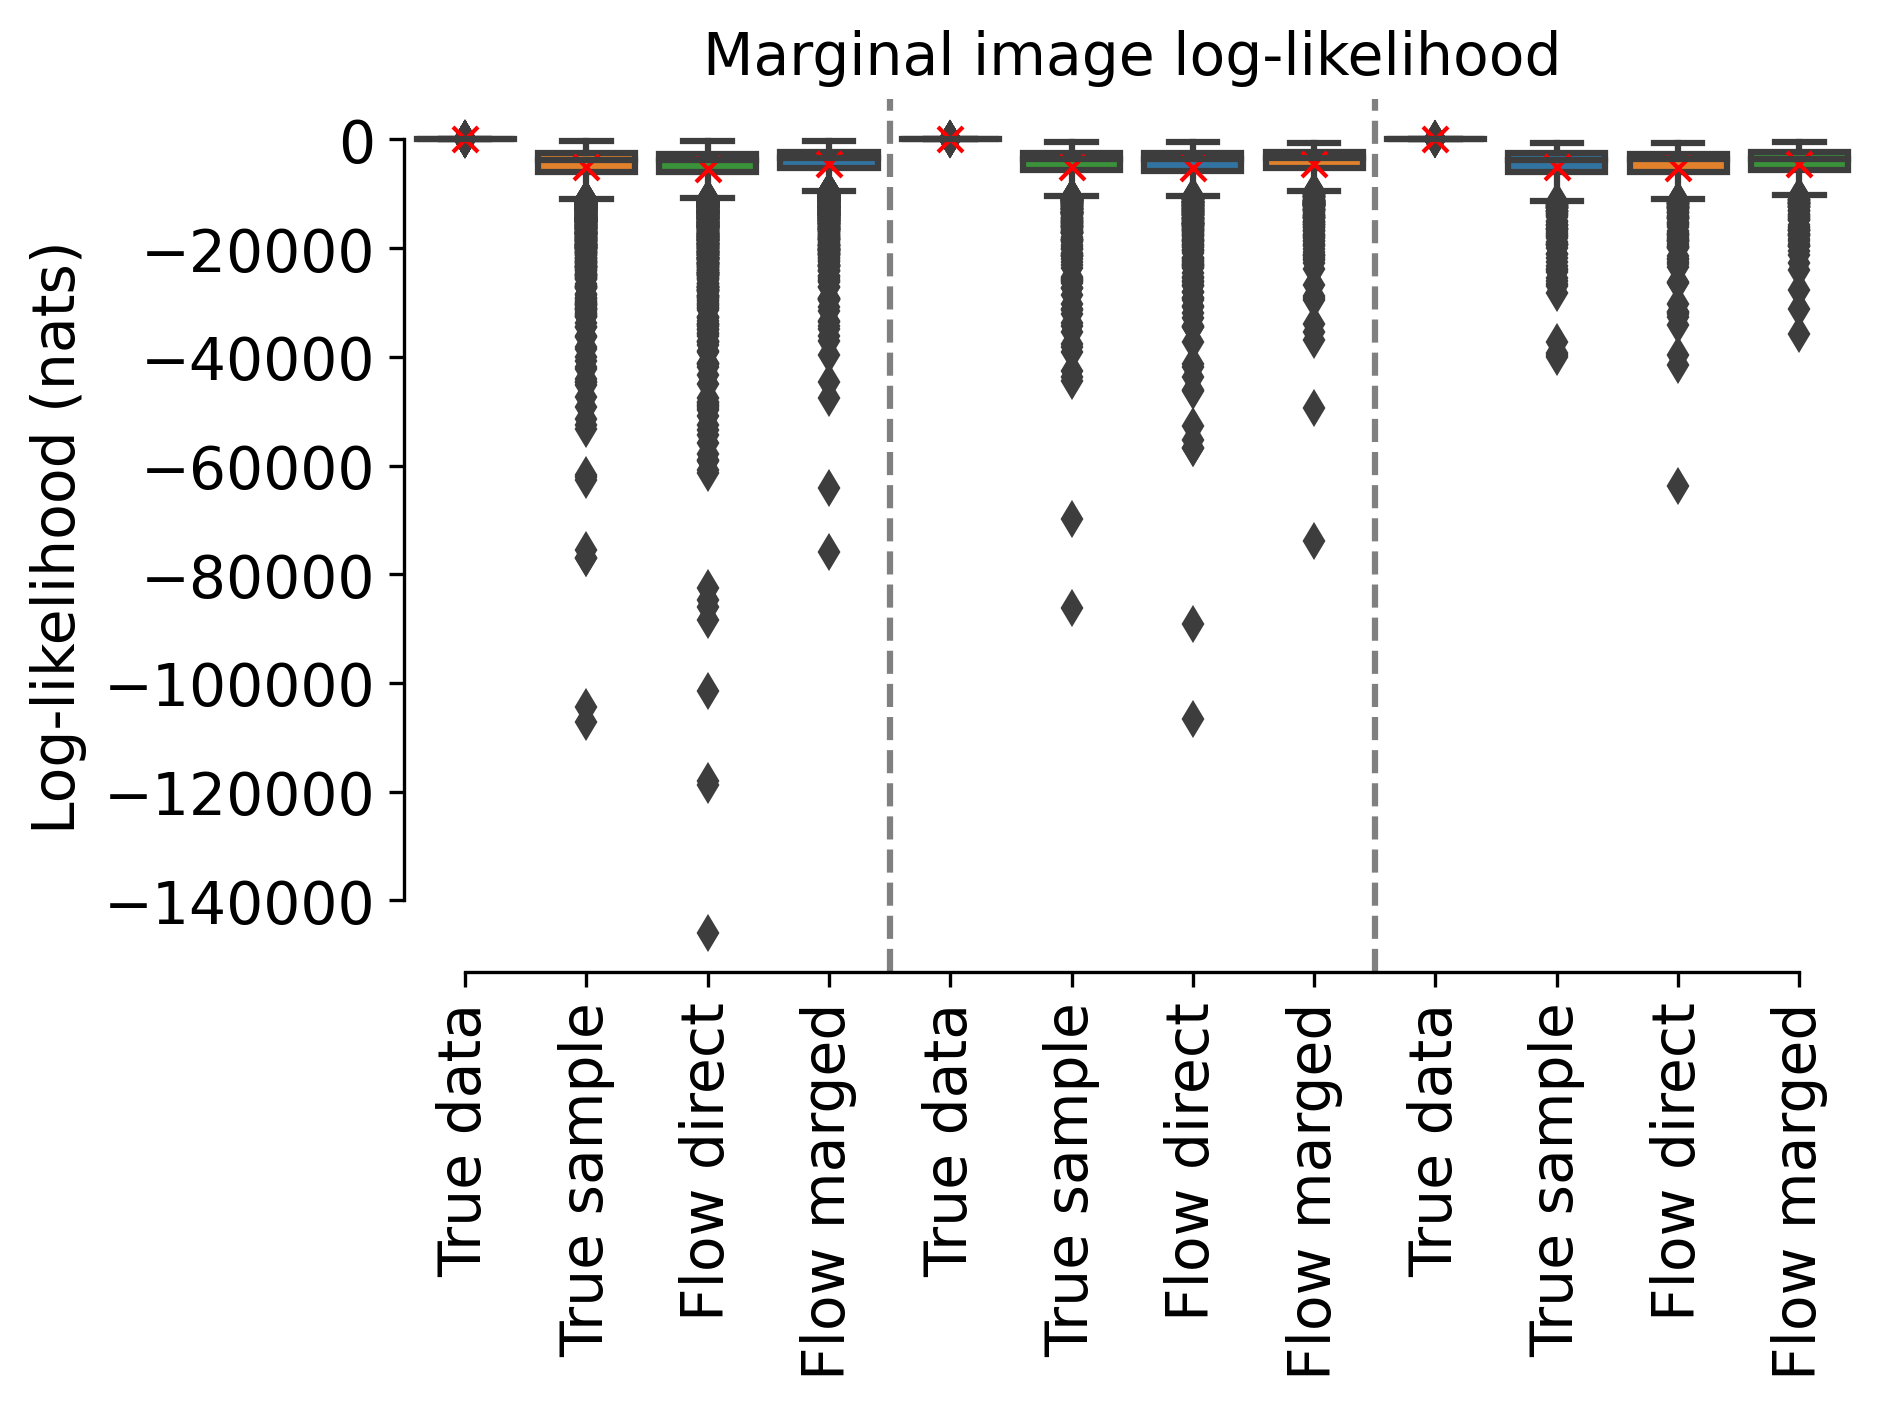

In [21]:
data = [
    true_data_logl_marg_train.detach(),
    true_logl_marg_train.detach(),
    logl_mc_marg_pre_task_train.detach(),
    logl_mc_marg_adpt_train.detach(),
    true_data_logl_marg_val.detach(),
    true_logl_marg_val.detach(),
    logl_mc_marg_pre_task_val.detach(),
    logl_mc_marg_adpt_val.detach(),
    true_data_logl_marg_test.detach(),
    true_logl_marg_test.detach(),
    logl_mc_marg_pre_task_test.detach(),
    logl_mc_marg_adpt_test.detach(),
]
labels = [
    "True data",
    "True sample",
    "Flow direct",
    "Flow marged",

    "True data",
    "True sample",
    "Flow direct",
    "Flow marged",

    "True data",
    "True sample",
    "Flow direct",
    "Flow marged",
]
# Creating a boxplot
fig, ax = plt.subplots(dpi=300)
# set two colors as palette and cycle
palette = sns.color_palette("tab10", n_colors=3)
ax = sns.boxplot(data=data, ax=ax, palette=palette)
# add mean values
for i, value in enumerate(data):
    # ax.text(i + 0.3, value.mean() + 0.5, f"{value.mean():.2f}", ha="center", va="bottom", fontsize=8)
    # add a red dot
    ax.plot(i, value.mean(), "rx")
ax.set_xticklabels(labels, rotation=90)
ax.set_title("Marginal image log-likelihood", fontsize=14)
ax.set_ylabel("Log-likelihood (nats)", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
for tick in range(len(labels)):
    if tick % 4 == 0 and tick != 0:
        ax.axvline(tick - 0.5, ls="--", color="grey")
# ax.set_yticks(range(-100, 0, 10))
sns.despine(ax=ax, trim=True)
plt.tight_layout()

# # Display the plot
# plt.show()

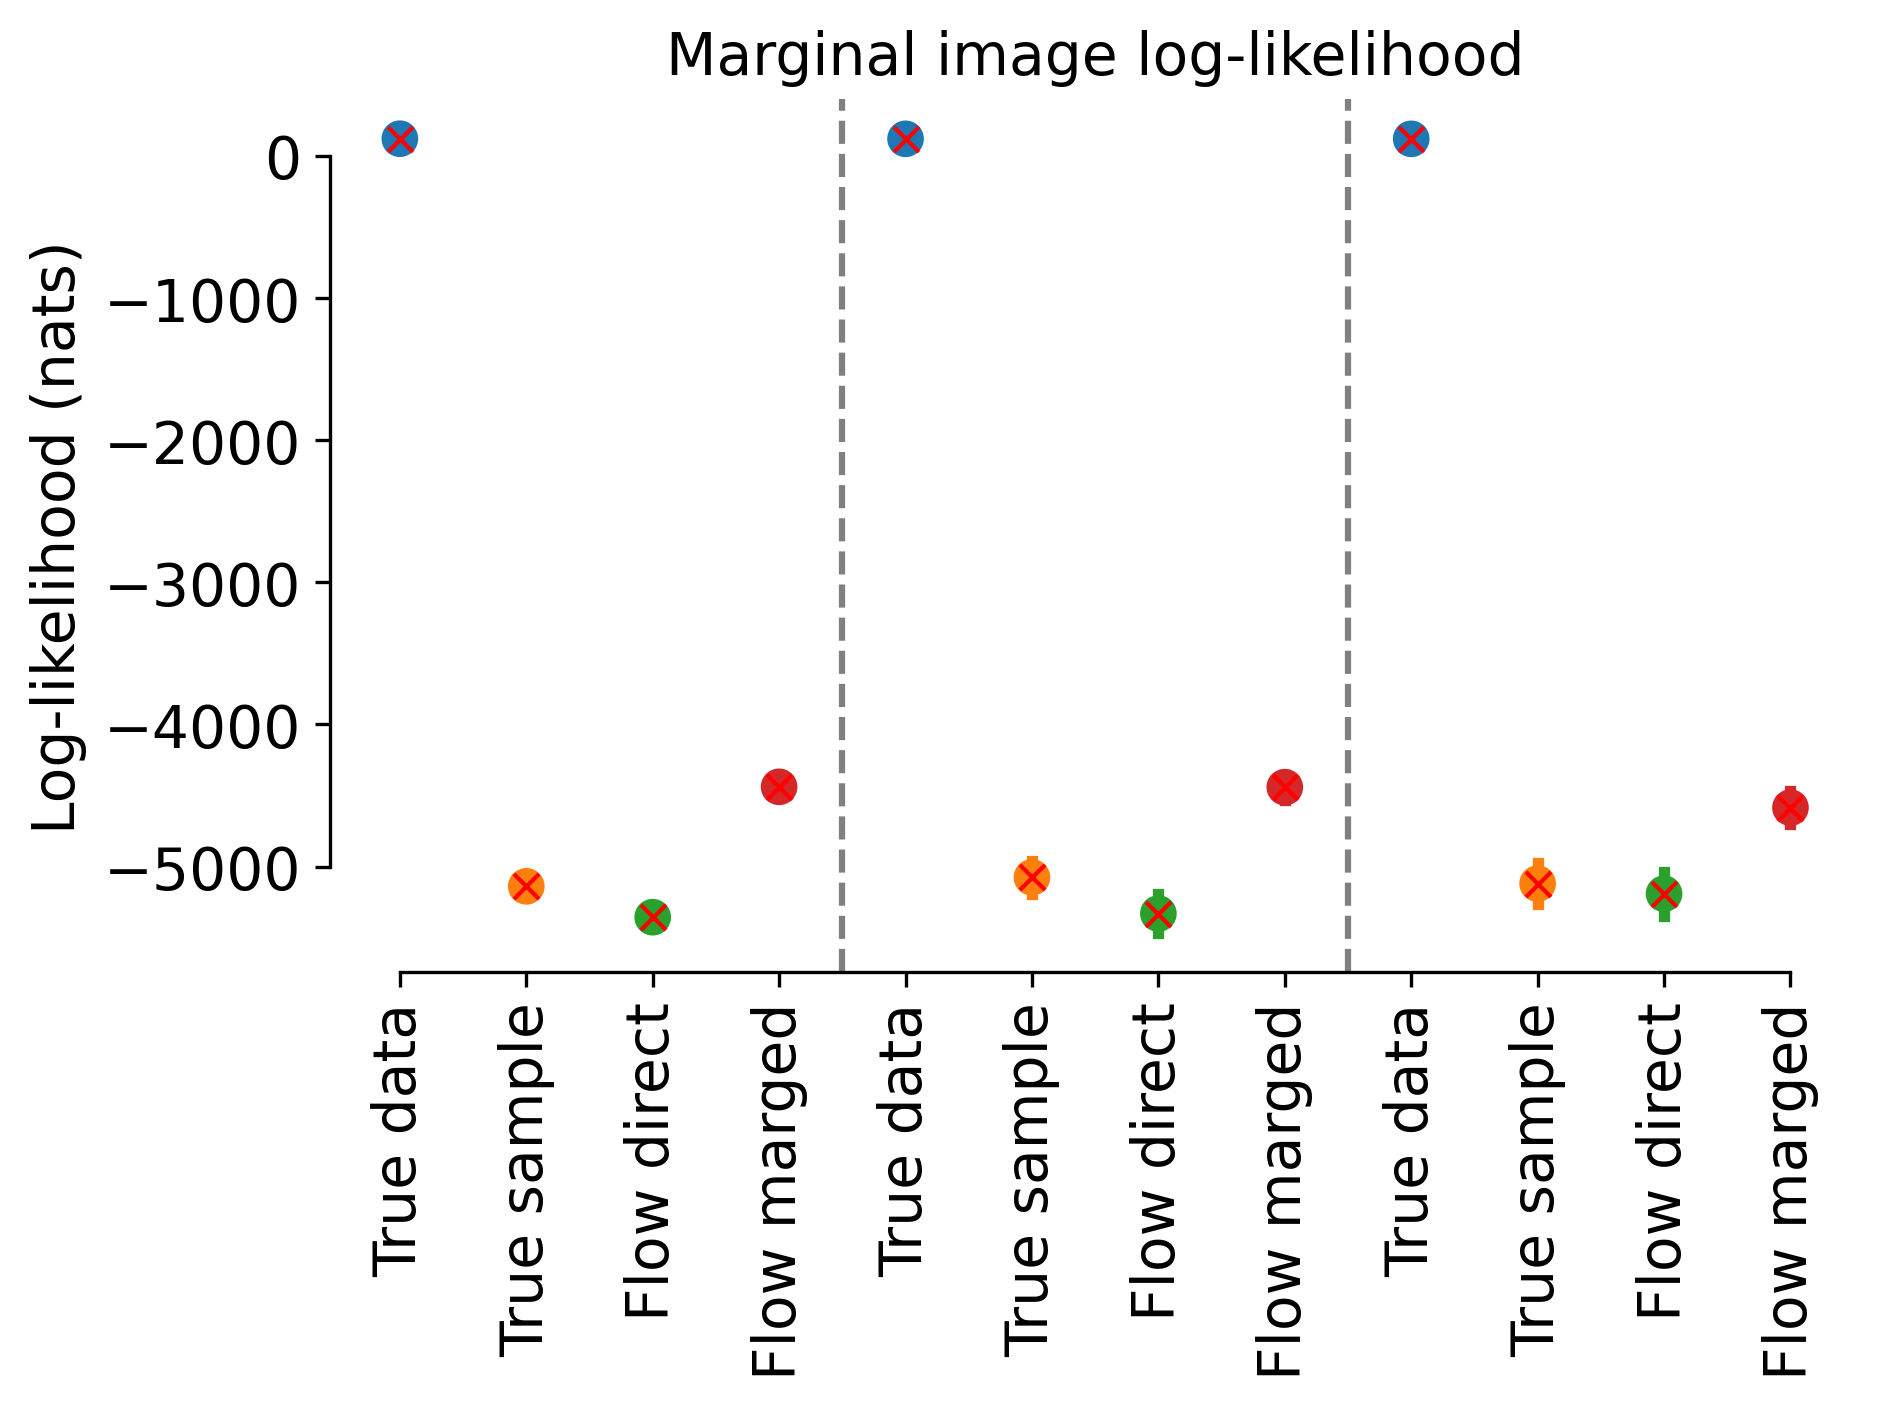

In [22]:
fig, ax = plt.subplots(dpi=300)
# set two colors as palette and cycle
palette = sns.color_palette("tab10", n_colors=4)
ax = sns.pointplot(data=data, ax=ax, palette=palette, errorbar="se")
# add mean values
for i, value in enumerate(data):
    # ax.text(i + 0.3, value.mean() + 0.5, f"{value.mean():.2f}", ha="center", va="bottom", fontsize=8)
    # add a red dot
    ax.plot(i, value.mean(), "rx")
ax.set_xticklabels(labels, rotation=90)
ax.set_title("Marginal image log-likelihood", fontsize=14)
ax.set_ylabel("Log-likelihood (nats)", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
for tick in range(len(labels)):
    if tick % 4 == 0 and tick != 0:
        ax.axvline(tick - 0.5, ls="--", color="grey")
# ax.set_yticks(range(-100, 0, 10))
sns.despine(ax=ax, trim=True)
plt.tight_layout()

# # Display the plot
# plt.show()

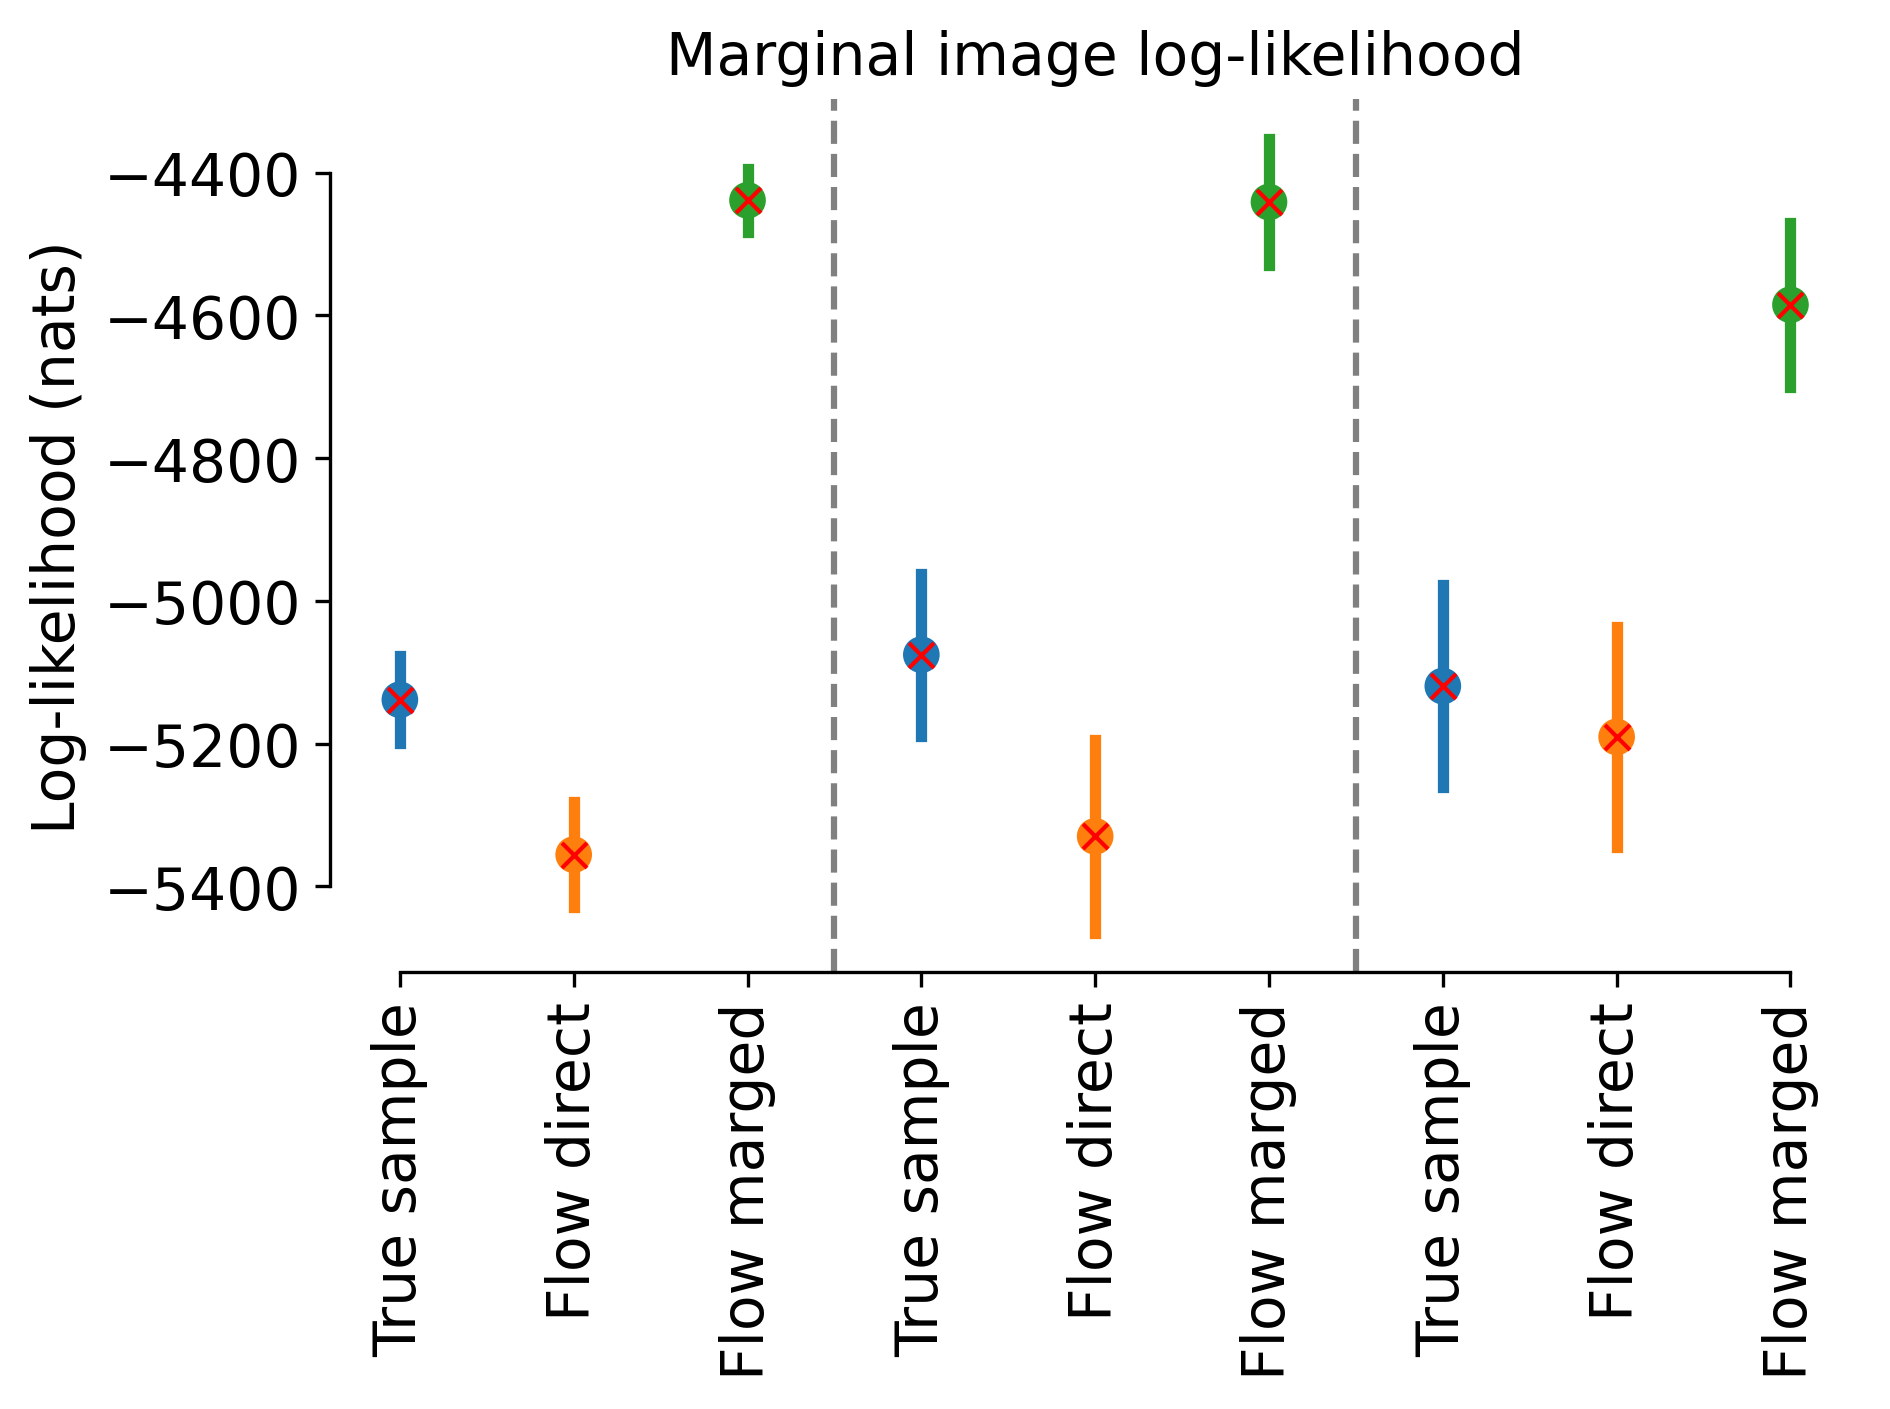

In [19]:
data = [

    true_logl_marg_train.detach(),
    logl_mc_marg_pre_task_train.detach(),
    logl_mc_marg_adpt_train.detach(),

    true_logl_marg_val.detach(),
    logl_mc_marg_pre_task_val.detach(),
    logl_mc_marg_adpt_val.detach(),

    true_logl_marg_test.detach(),
    logl_mc_marg_pre_task_test.detach(),
    logl_mc_marg_adpt_test.detach(),
]
labels = [

    "True sample",
    "Flow direct",
    "Flow marged",


    "True sample",
    "Flow direct",
    "Flow marged",


    "True sample",
    "Flow direct",
    "Flow marged",
]
# Creating a boxplot
fig, ax = plt.subplots(dpi=300)
# set two colors as palette and cycle
palette = sns.color_palette("tab10", n_colors=3)
ax = sns.pointplot(data=data, ax=ax, palette=palette, errorbar="se")
# add mean values
for i, value in enumerate(data):
    # ax.text(i + 0.3, value.mean() + 0.5, f"{value.mean():.2f}", ha="center", va="bottom", fontsize=8)
    # add a red dot
    ax.plot(i, value.mean(), "rx")
ax.set_xticklabels(labels, rotation=90)
ax.set_title("Marginal image log-likelihood", fontsize=14)
ax.set_ylabel("Log-likelihood (nats)", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
for tick in range(len(labels)):
    if tick % 3 == 0 and tick != 0:
        ax.axvline(tick - 0.5, ls="--", color="grey")
# ax.set_yticks(range(-100, 0, 10))
sns.despine(ax=ax, trim=True)
plt.tight_layout()

# # Display the plot
# plt.show()

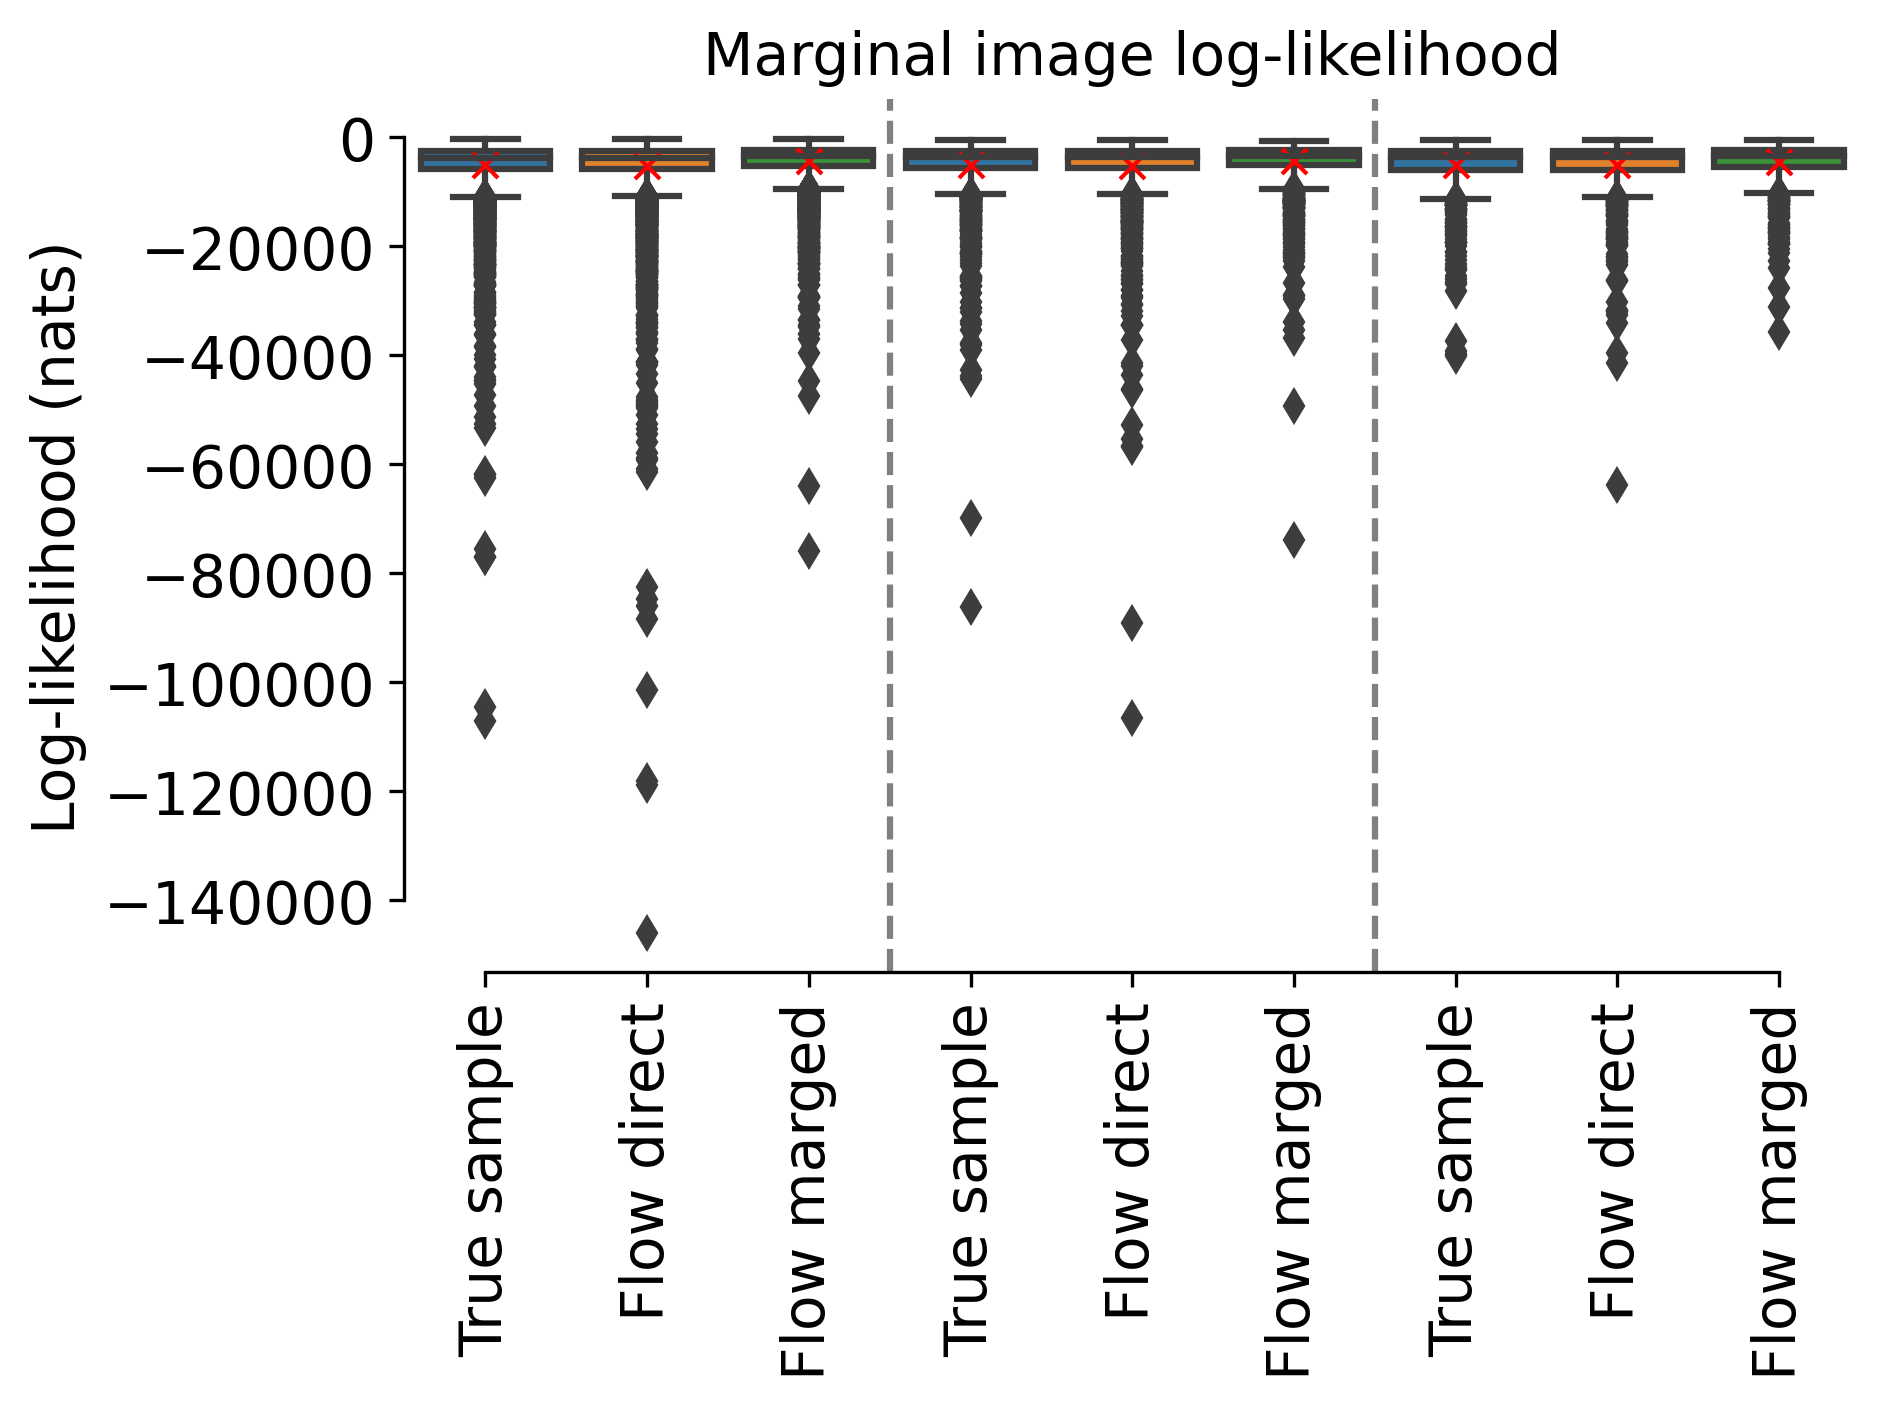

In [18]:
# Creating a boxplot
fig, ax = plt.subplots(dpi=300)
# set two colors as palette and cycle
palette = sns.color_palette("tab10", n_colors=3)
ax = sns.boxplot(data=data, ax=ax, palette=palette)
# add mean values
for i, value in enumerate(data):
    # ax.text(i + 0.3, value.mean() + 0.5, f"{value.mean():.2f}", ha="center", va="bottom", fontsize=8)
    # add a red dot
    ax.plot(i, value.mean(), "rx")
ax.set_xticklabels(labels, rotation=90)
ax.set_title("Marginal image log-likelihood", fontsize=14)
ax.set_ylabel("Log-likelihood (nats)", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
for tick in range(len(labels)):
    if tick % 3 == 0 and tick != 0:
        ax.axvline(tick - 0.5, ls="--", color="grey")
# ax.set_yticks(range(-100, 0, 10))
sns.despine(ax=ax, trim=True)
plt.tight_layout()

# # Display the plot
# plt.show()